# Vocabulary Mapping Coverage

Every clinical event this pipeline loads carries two concept IDs: the source
code as originally recorded, and the standard concept it resolves to after
`VocabularyMapper` walks the "Maps to" relationship (see
`src/transform/vocabulary_mapper.py`). Not everything resolves — a demo-scale
vocabulary seed doesn't cover every code a real population would produce, on
purpose (`scripts/demo_codes.py` deliberately omits a couple of source codes
so this pipeline's quality tooling has a real gap to report instead of a
trivial 100%).

This notebook answers one question per clinical domain: of everything loaded,
how much actually resolved to a standard concept?

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, "..")
sys.path.insert(0, ".")
from src.config.settings import settings

# Jupyter's kernel CWD is this notebook's own folder, but settings.duckdb_path
# defaults to a path relative to CWD — left alone, that resolves to
# notebooks/data/... and every query below would silently open a fresh,
# empty database instead of the real one at the repo root.
settings.duckdb_path = Path("../data/processed/omop_demo.duckdb")
import duckdb

con = duckdb.connect("../data/processed/omop_demo.duckdb")

domains = [
    ("Condition", "condition_occurrence", "condition_concept_id"),
    ("Drug", "drug_exposure", "drug_concept_id"),
    ("Measurement", "measurement", "measurement_concept_id"),
]

rows = []
for label, table, col in domains:
    total = con.execute(f"select count(*) from cdm.{table}").fetchone()[0]
    unmapped = con.execute(f"select count(*) from cdm.{table} where {col} = 0").fetchone()[0]
    rows.append((label, total - unmapped, unmapped))
    print(f"{label:12s} {total-unmapped:>7,} / {total:>7,} mapped ({100*(total-unmapped)/total:.1f}%)")
con.close()


Condition      4,090 /   4,180 mapped (97.8%)
Drug           2,898 /   2,950 mapped (98.2%)
Measurement  413,950 / 413,950 mapped (100.0%)


## The chart

Three gauge dials, one per domain — not a Sankey. A Sankey normalized to equal
width per domain solves the same "measurement dwarfs everything else" problem a
gauge solves for free: a percentage read off a dial doesn't care how many rows
sit behind it. Hand-built SVG, not a chart library — full writeup of the
redesign in `notebooks/dope_viz.py`'s module docstring.

The unfilled arc is drawn in red at low opacity rather than a neutral gray, on
purpose: a 2% gap should still read as a gap at a glance, not disappear into
the dark background because the leftover space happened to render in a color
that blends in.


Saved docs/assets/visualizations/vocabulary_mapping_sankey.svg and vocabulary_mapping_sankey.png


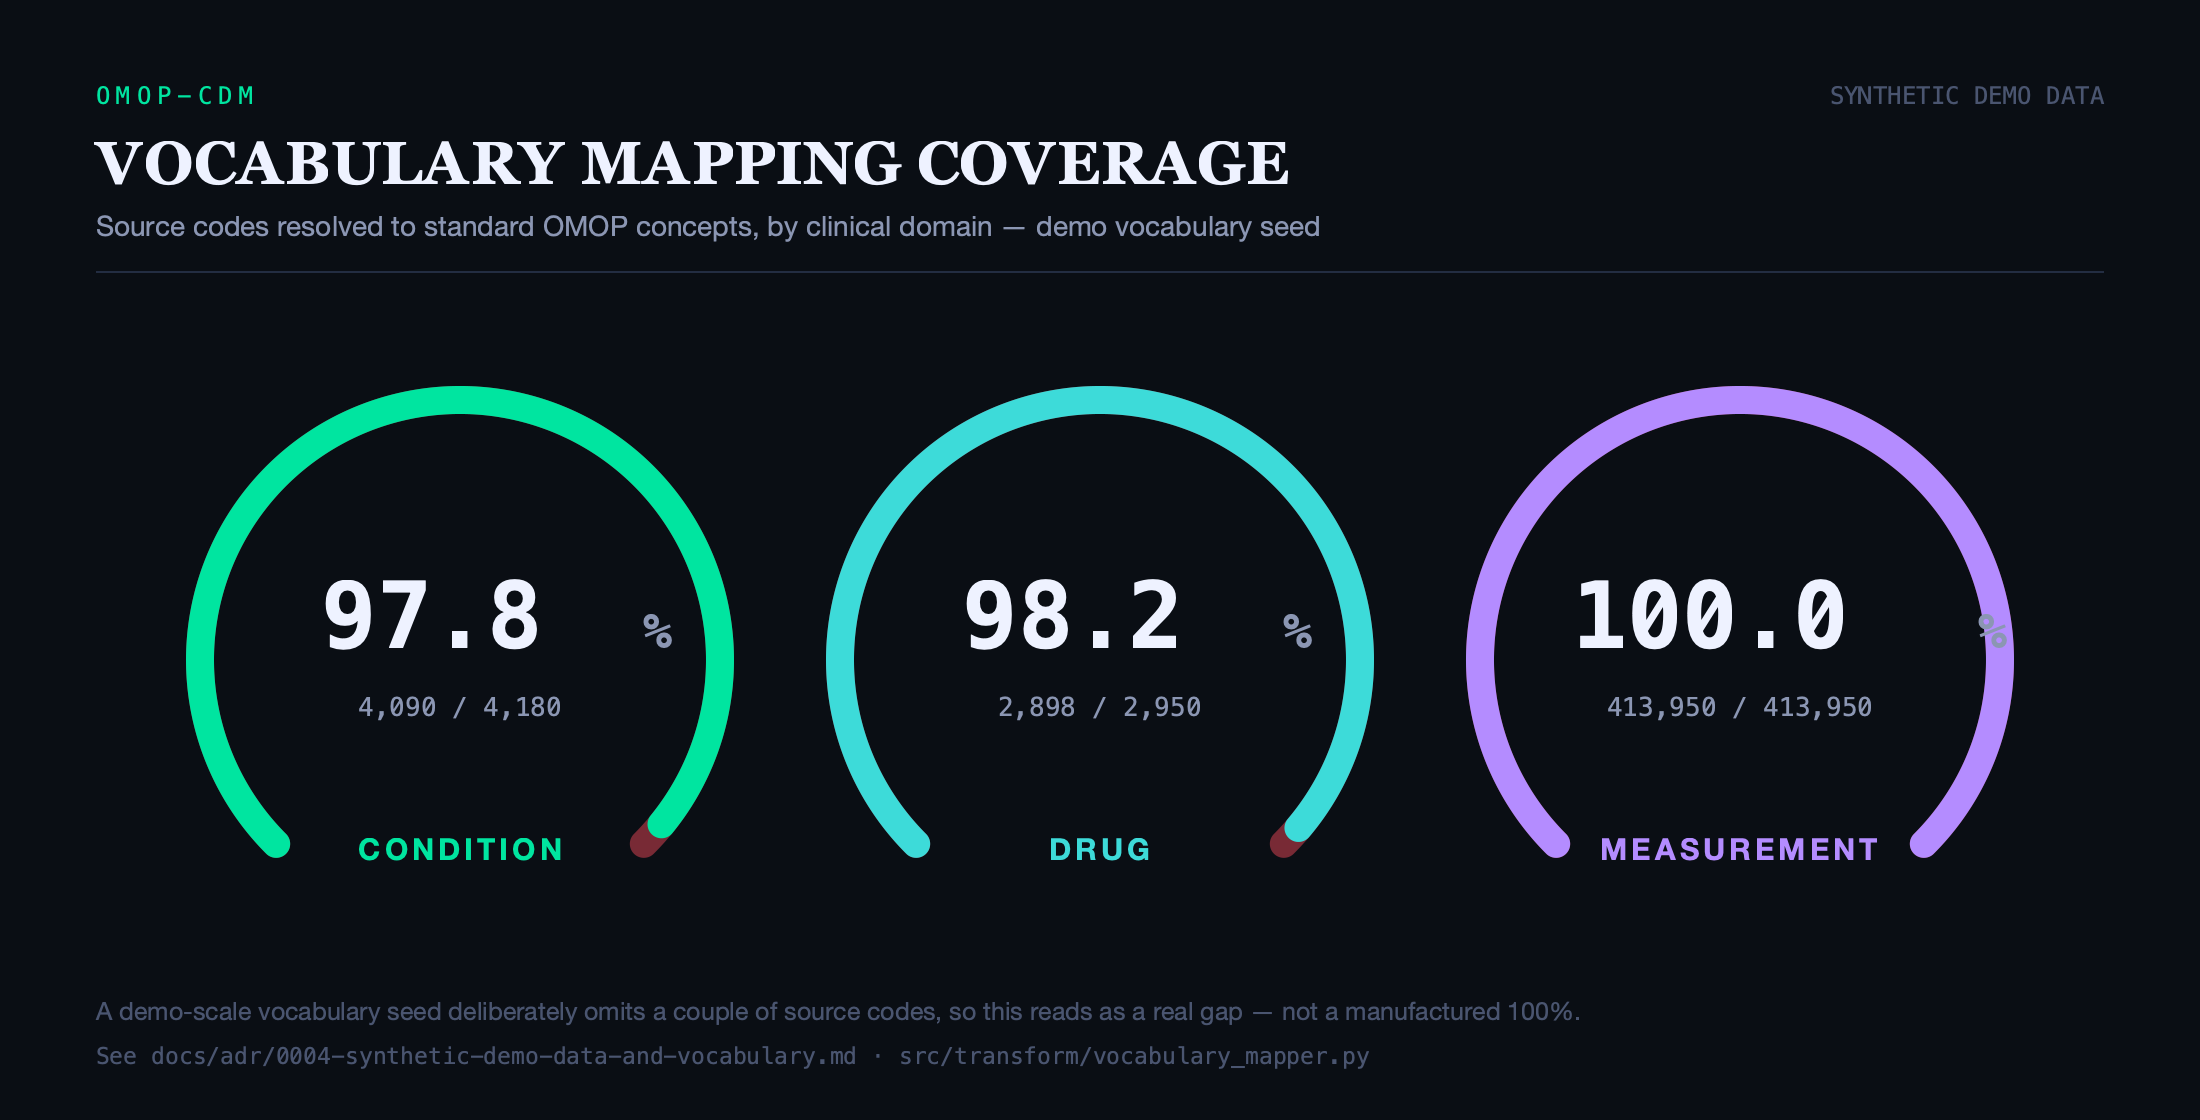

In [2]:
import subprocess
import sys
from IPython.display import Image

subprocess.run([sys.executable, "notebooks/build_vocabulary_mapping.py"], cwd="..", check=True)
Image(filename="../docs/assets/visualizations/vocabulary_mapping_sankey.png")


## Reading this

Condition and drug both show a thin red sliver — a handful of codes this
demo's vocabulary seed doesn't cover, on purpose. Measurement resolves at
100% because every LOINC code the data generator emits has a matching row in
the seed. In production, against a full Athena download, the unmapped
fraction is the number a real vocabulary-mapping effort tracks over time as
more of the source coding system gets curated.